# FT5010 Final Project

This notebook contains the final backtest used for our FX strategy project.

The idea is to test a multi-rule trend following setup on major USD pairs, then check both train/test performance and whether the strategy is active enough in short live-style windows.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import queue

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)

## 1. Strategy setup

The core idea is still based on Carver-style trend trading, but kept fairly simple here.

Main pieces used in this notebook:
- EWMAC rules at several speeds
- scaling each raw rule to a similar forecast range
- combining the rules into one forecast
- applying a forecast diversification multiplier from the training set


In [2]:
# three EWMAC speeds used in the base version
FAST_SLOW_PAIRS = ((64, 256), (128, 512), (256, 1024))

# 70% weight to trend, 30% to reversal
TREND_WEIGHT = 0.70
REVERSAL_WEIGHT = 0.30

# reversal looks back 72 hours (~3 days)
REVERSAL_LOOKBACK = 72

# vol gate settings
VOL_GATE_ENABLED = True
VOL_REALIZED_WINDOW = 24 * 7       # 1 week of hourly bars
VOL_PERCENTILE_WINDOW = 24 * 30 * 6  # 6 months
VOL_CUTOFF = 0.90                  # top 10% vol -> reduce position
VOL_SCALE = 0.5                    # scale down to 50%

TARGET_FORECAST = 10.0   # we want mean abs forecast to be 10
CAP_FORECAST = 20.0      # hard cap
PRICE_VOL_SPAN = 120     # ewm span for price vol estimate
MIN_TRAIN_OBS = 2000
LOT_SIZE = 1000
NO_TRADE_BUFFER = 0.10
CORR_FLOOR = 0.05        # avoid division by near-zero correlation

In [3]:
# used to normalize raw signals
def calc_price_vol(close):
    vol = close.diff().ewm(span=PRICE_VOL_SPAN, adjust=False, min_periods=PRICE_VOL_SPAN).std()
    return vol.clip(lower=1e-12)


# raw EWMAC signal (not yet scaled)
def calc_ewmac(close, fast, slow, price_vol):
    fast_ma = close.ewm(span=fast, adjust=False, min_periods=fast).mean()
    slow_ma = close.ewm(span=slow, adjust=False, min_periods=slow).mean()
    raw = (fast_ma - slow_ma) / price_vol
    return raw.replace([np.inf, -np.inf], np.nan)


# raw reversal signal - negative of recent move
def calc_reversal(close, price_vol, lookback):
    move = close - close.shift(lookback)
    raw = -move / price_vol
    return raw.replace([np.inf, -np.inf], np.nan)


# vol regime gate - returns 1.0 normally, 0.5 in high vol periods
def calc_vol_gate(close):
    if not VOL_GATE_ENABLED:
        return pd.Series(1.0, index=close.index)
    realized = close.pct_change().rolling(VOL_REALIZED_WINDOW, min_periods=VOL_REALIZED_WINDOW).std()
    pct_rank = realized.rolling(VOL_PERCENTILE_WINDOW, min_periods=VOL_PERCENTILE_WINDOW // 2).rank(pct=True)
    gate = pd.Series(1.0, index=close.index)
    gate[pct_rank > VOL_CUTOFF] = VOL_SCALE
    return gate.fillna(1.0)


# helper - scalar to bring mean abs value to TARGET_FORECAST
def calc_scalar(raw_signal):
    x = raw_signal.replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) == 0:
        return np.nan
    mean_abs = x.abs().mean()
    if mean_abs <= 0 or pd.isna(mean_abs):
        return np.nan
    return TARGET_FORECAST / mean_abs


# compute rule weights based on correlation between trend signals
# idea: down-weight rules that are highly correlated with each other
def calc_rule_weights(forecast_df):
    trend_cols = [f'forecast_ewmac_{f}_{s}' for f, s in FAST_SLOW_PAIRS]
    tdf = forecast_df[trend_cols].dropna()
    
    if len(tdf) < 20:
        # not enough data, use equal weights
        trend_w = {c: 1/len(trend_cols) for c in trend_cols}
    else:
        corr = tdf.corr().fillna(0.0)
        scores = {}
        for c in trend_cols:
            others = [x for x in trend_cols if x != c]
            avg_corr = max(float(corr.loc[c, others].mean()), CORR_FLOOR)
            scores[c] = 1.0 / avg_corr
        total = sum(scores.values())
        trend_w = {k: v / total for k, v in scores.items()}
    
    weights = {c: TREND_WEIGHT * trend_w[c] for c in trend_cols}
    weights['forecast_reversal'] = REVERSAL_WEIGHT
    return weights

In [4]:
# fit on train data and keep the pieces needed later
def fit_strategy(train_df):
    close = train_df['close'].astype(float)
    price_vol = calc_price_vol(close)
    
    # build raw signals
    raw_signals = {}
    for fast, slow in FAST_SLOW_PAIRS:
        raw_signals[f'ewmac_{fast}_{slow}'] = calc_ewmac(close, fast, slow, price_vol)
    raw_signals['reversal'] = calc_reversal(close, price_vol, REVERSAL_LOOKBACK)
    
    # compute scalars from training data
    scalars = {}
    for name, raw in raw_signals.items():
        sc = calc_scalar(raw)
        if name == 'reversal' and not np.isfinite(sc):
            sc = 0.0
        scalars[name] = sc
    
    # scaled + clipped forecasts (training period)
    forecast_df = pd.DataFrame(index=train_df.index)
    for fast, slow in FAST_SLOW_PAIRS:
        key = f'ewmac_{fast}_{slow}'
        forecast_df[f'forecast_{key}'] = (raw_signals[key] * scalars[key]).clip(-CAP_FORECAST, CAP_FORECAST)
    forecast_df['forecast_reversal'] = (raw_signals['reversal'] * scalars['reversal']).clip(-CAP_FORECAST, CAP_FORECAST)
    
    # rule weights
    rule_weights = calc_rule_weights(forecast_df)
    
    # combined forecast on training set
    combined = sum(forecast_df[c] * w for c, w in rule_weights.items())
    
    # FDM - forecast diversification multiplier
    x = combined.replace([np.inf, -np.inf], np.nan).dropna()
    mac = x.abs().mean()
    if pd.isna(mac) or mac <= 0:
        raise ValueError('Cannot compute FDM - check training data')
    fdm = TARGET_FORECAST / mac
    
    return {'scalars': scalars, 'rule_weights': rule_weights, 'fdm': fdm}


# apply fitted params to any dataframe (train or test)
def transform_strategy(df, params):
    close = df['close'].astype(float)
    price_vol = calc_price_vol(close)
    
    out = pd.DataFrame(index=df.index)
    out['close'] = close
    out['price_vol_points'] = price_vol
    
    scalars = params['scalars']
    rule_weights = params['rule_weights']
    fdm = params['fdm']
    
    for fast, slow in FAST_SLOW_PAIRS:
        key = f'ewmac_{fast}_{slow}'
        raw = calc_ewmac(close, fast, slow, price_vol)
        out[f'raw_{key}'] = raw
        out[f'forecast_{key}'] = (raw * scalars[key]).clip(-CAP_FORECAST, CAP_FORECAST)
    
    raw_rev = calc_reversal(close, price_vol, REVERSAL_LOOKBACK)
    out['raw_reversal'] = raw_rev
    out['forecast_reversal'] = (raw_rev * scalars['reversal']).clip(-CAP_FORECAST, CAP_FORECAST)
    
    combined_raw = sum(out[c] * w for c, w in rule_weights.items())
    out['combined_forecast_raw'] = combined_raw
    combined = (combined_raw * fdm).clip(-CAP_FORECAST, CAP_FORECAST)
    
    gate = calc_vol_gate(close)
    out['vol_gate'] = gate
    
    # smooth the final forecast a bit
    smoothed = (combined * gate).ewm(span=8, min_periods=1).mean()
    out['combined_forecast'] = smoothed.clip(-CAP_FORECAST, CAP_FORECAST)
    
    return out

## 2. Backtest structure

This is still event-driven, but only with the pieces we need here:
- market event
- signal event
- order event
- fill event


In [5]:
# event classes

class MarketEvent:
    def __init__(self, timestamp, bars):
        self.timestamp = timestamp
        self.bars = bars   # dict: symbol -> pd.Series

class SignalEvent:
    def __init__(self, timestamp, symbol, forecast, price_vol_points, close, quote_to_account):
        self.timestamp = timestamp
        self.symbol = symbol
        self.forecast = forecast
        self.price_vol_points = price_vol_points
        self.close = close
        self.quote_to_account = quote_to_account

class OrderEvent:
    def __init__(self, timestamp, symbol, target_units):
        self.timestamp = timestamp
        self.symbol = symbol
        self.target_units = target_units

class FillEvent:
    def __init__(self, timestamp, symbol, trade_units, fill_price, commission, quote_to_account):
        self.timestamp = timestamp
        self.symbol = symbol
        self.trade_units = trade_units
        self.fill_price = fill_price
        self.commission = commission
        self.quote_to_account = quote_to_account

In [6]:
# feed bars one by one
class DataHandler:
    def __init__(self, data, start=None, end=None):
        frames = {}
        for sym, df in data.items():
            d = df.sort_index().copy()
            if start is not None:
                d = d.loc[pd.to_datetime(start):]
            if end is not None:
                d = d.loc[:pd.to_datetime(end)]
            if 'quote_to_account' not in d.columns:
                d['quote_to_account'] = 1.0
            if 'open' not in d.columns:
                d['open'] = d['close']
            frames[sym] = d
        self.data = frames
        self.symbols = list(frames.keys())
        # unified timeline across all pairs
        self.timeline = sorted(set().union(*[df.index for df in frames.values()]))
        self._i = 0

    def __iter__(self):
        self._i = 0
        return self

    def __next__(self):
        if self._i >= len(self.timeline):
            raise StopIteration
        ts = self.timeline[self._i]
        bars = {s: df.loc[ts] for s, df in self.data.items() if ts in df.index}
        self._i += 1
        return MarketEvent(timestamp=ts, bars=bars)

    def get_next_open(self, symbol, ts):
        df = self.data[symbol]
        idx = df.index.searchsorted(ts, side='right')
        if idx >= len(df.index):
            return None
        return float(df.iloc[idx]['open'])

In [7]:
# read cached forecasts and emit signals
class StrategyWrapper:
    def __init__(self, fitted_params, full_data):
        # build forecast tables once
        self.signals = {}
        for sym, params in fitted_params.items():
            self.signals[sym] = transform_strategy(full_data[sym], params)

    def on_market(self, ev):
        out = []
        for sym, row in ev.bars.items():
            sig_df = self.signals.get(sym)
            if sig_df is None or ev.timestamp not in sig_df.index:
                continue
            sr = sig_df.loc[ev.timestamp]
            f = sr.get('combined_forecast', np.nan)
            pv = sr.get('price_vol_points', np.nan)
            if not np.isfinite(f) or not np.isfinite(pv) or pv <= 0:
                continue
            out.append(SignalEvent(
                timestamp=ev.timestamp,
                symbol=sym,
                forecast=float(f),
                price_vol_points=float(pv),
                close=float(row['close']),
                quote_to_account=float(row.get('quote_to_account', 1.0))
            ))
        return out

In [ ]:
# simple portfolio state and sizing

CAPITAL = 100_000.0
VOL_TARGET_ANN = 0.12    # 12% annual vol target
PORT_LOT_SIZE = 1000
PORT_NO_TRADE_BUFFER = 0.20
MAX_LEVERAGE = 4.0

class Portfolio:
    def __init__(self, symbols, capital=CAPITAL):
        self.capital0 = capital
        self.cash = capital
        self.symbols = symbols
        self.positions = {s: 0.0 for s in symbols}
        self.last_price = {s: np.nan for s in symbols}
        # same weight for each pair
        self.weights = {s: 1.0 / len(symbols) for s in symbols}
        self.equity_curve = []
        self.trades = []

    def mark_to_market(self, ev):
        pnl = 0.0
        for sym, row in ev.bars.items():
            close = float(row['close'])
            qta = float(row.get('quote_to_account', 1.0))
            prev = self.last_price[sym]
            if self.positions[sym] != 0 and np.isfinite(prev):
                pnl += self.positions[sym] * (close - prev) * qta
            self.last_price[sym] = close
        return pnl

    def on_market(self, ev):
        pnl = self.mark_to_market(ev)
        self.cash += pnl
        self.equity_curve.append({'timestamp': ev.timestamp, 'equity': self.cash, 'pnl': pnl})

    def on_signal(self, sig):
        # capital slice for this pair
        inst_cap = self.cash * self.weights[sig.symbol]
        
        # daily cash risk target
        daily_cash_vol = (inst_cap * VOL_TARGET_ANN) / 16.0
        
#pair vol in accountccy
        inst_vol = sig.price_vol_points * sig.quote_to_account
        if not np.isfinite(inst_vol) or inst_vol <= 0:
            return None
        
        # units per 1 forecast point
        vol_scalar = daily_cash_vol / inst_vol
        target = vol_scalar * sig.forecast / TARGET_FORECAST
        
        # keep leverage under control
        max_notional = MAX_LEVERAGE * inst_cap
        max_units = max_notional / max(sig.close * sig.quote_to_account, 1e-9)
        target = float(np.clip(target, -max_units, max_units))
        
        # round to lot
        target = np.round(target / PORT_LOT_SIZE) * PORT_LOT_SIZE
        
        cur = self.positions[sig.symbol]
        
        # skip small rebalances
        denom = max(abs(cur), PORT_LOT_SIZE)
        if cur != 0 and abs(target - cur) / denom <= PORT_NO_TRADE_BUFFER:
            return None
        if target == cur:
            return None
        
        return OrderEvent(timestamp=sig.timestamp, symbol=sig.symbol, target_units=target)

    def on_fill(self, fill):
        self.positions[fill.symbol] += fill.trade_units
        self.cash -= fill.commission
        self.trades.append({
            'timestamp': fill.timestamp,
            'symbol': fill.symbol,
            'trade_units': fill.trade_units,
            'fill_price': fill.fill_price,
            'commission': fill.commission,
            'position_after': self.positions[fill.symbol]
        })

In [9]:
# basic execution model

SPREAD_BPS = 0.5   # typical FX spread assumption

class ExecutionHandler:
    def __init__(self, data_handler):
        self.dh = data_handler

    def execute(self, order, portfolio):
        cur = portfolio.positions[order.symbol]
        trade = order.target_units - cur
        if trade == 0:
            return None
        
        df = self.dh.data[order.symbol]
        if order.timestamp not in df.index:
            return None
        row = df.loc[order.timestamp]
        
        # use next bar open
        fp = self.dh.get_next_open(order.symbol, order.timestamp)
        if fp is None:
            fp = float(row['close'])
        
        qta = float(row.get('quote_to_account', 1.0))
        slip = fp * (SPREAD_BPS / 1e4) * np.sign(trade)
        fill_price = fp + slip
        commission = abs(trade) * abs(slip) * qta
        
        return FillEvent(
            timestamp=order.timestamp,
            symbol=order.symbol,
            trade_units=trade,
            fill_price=fill_price,
            commission=commission,
            quote_to_account=qta
        )

In [10]:
# backtest loop
def run_backtest(data, fitted_params, capital=CAPITAL, start=None, end=None):
    dh = DataHandler(data, start=start, end=end)
    if len(dh.timeline) == 0:
        raise ValueError(f'No bars in window {start} to {end}')
    
    strategy = StrategyWrapper(fitted_params, data)
    portfolio = Portfolio(dh.symbols, capital=capital)
    execution = ExecutionHandler(dh)
    events = queue.Queue()
    
    for mkt in dh:
        events.put(mkt)
        while not events.empty():
            ev = events.get()
            if isinstance(ev, MarketEvent):
                portfolio.on_market(ev)
                for sig in strategy.on_market(ev):
                    events.put(sig)
            elif isinstance(ev, SignalEvent):
                order = portfolio.on_signal(ev)
                if order is not None:
                    events.put(order)
            elif isinstance(ev, OrderEvent):
                fill = execution.execute(ev, portfolio)
                if fill is not None:
                    events.put(fill)
            elif isinstance(ev, FillEvent):
                portfolio.on_fill(ev)
    
    eq = pd.DataFrame(portfolio.equity_curve).set_index('timestamp')
    eq['returns'] = eq['equity'].pct_change().fillna(0.0)
    trades = pd.DataFrame(portfolio.trades)
    return eq, trades

## 3. Metrics

In [11]:
# rough annualisation for H1 FX bars
HOURS_PER_YEAR = 24 * 5 * 52

def calc_metrics(equity, trades=None, capital0=100_000.0):
    r = equity['returns'].dropna()
    e = equity['equity']
    
    total_ret = e.iloc[-1] / e.iloc[0] - 1
    years = len(r) / HOURS_PER_YEAR
    cagr = (1 + total_ret) ** (1 / years) - 1
    ann_vol = r.std() * np.sqrt(HOURS_PER_YEAR)
    sharpe = (r.mean() * HOURS_PER_YEAR) / (r.std() * np.sqrt(HOURS_PER_YEAR) + 1e-12)
    downside_vol = r[r < 0].std() * np.sqrt(HOURS_PER_YEAR)
    sortino = (r.mean() * HOURS_PER_YEAR) / (downside_vol + 1e-12)
    drawdown = e / e.cummax() - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    hit_rate = (r > 0).mean()

    out = {
        'TotalReturn': total_ret,
        'CAGR': cagr,
        'AnnVol': ann_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'MaxDrawdown': max_dd,
        'Calmar': calmar,
        'HitRate': hit_rate,
        'NumBars': len(r),
    }

    if trades is not None and len(trades) > 0:
        notional = (trades['trade_units'].abs() * trades['fill_price']).sum()
        avg_equity = e.mean()
        turnover_ann = (notional / max(avg_equity, 1e-9)) / max(years, 1e-9)
        total_comm = float(trades['commission'].sum())
        cost_drag = (total_comm / capital0) / max(years, 1e-9)

        # rough gross Sharpe, before commissions
        comm_by_ts = trades.groupby('timestamp')['commission'].sum().reindex(equity.index).fillna(0.0)
        gross_eq = e + comm_by_ts.cumsum()
        gross_ret = gross_eq.pct_change().fillna(0.0)
        gross_sharpe = (gross_ret.mean() * HOURS_PER_YEAR) / (gross_ret.std() * np.sqrt(HOURS_PER_YEAR) + 1e-12)

        out.update({
            'NumTrades': int(len(trades)),
            'TurnoverAnn(x)': turnover_ann,
            'TotalCommissions': total_comm,
            'CostDragAnn': cost_drag,
            'GrossSharpe': gross_sharpe,
            'CostDragOnSharpe': gross_sharpe - sharpe,
        })
    return out

## 4. Load market data

Use OANDA H1 data starting from 2020.

If needed, set `OANDA_TOKEN` in the environment before running the data section.


In [13]:
import sys, subprocess
try:
    import oandapyV20
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'oandapyV20'])
    import oandapyV20

import os

OANDA_TOKEN = os.environ.get('OANDA_TOKEN',
    '042919c9d89351ae2d6141778420434d-cdd631c6497843cd515172ea976b029d')
OANDA_ENV = os.environ.get('OANDA_ENV', 'practice')

UNIVERSE = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD']
ACCOUNT_CCY = 'USD'
START_DATE = '2020-01-01'
GRANULARITY = 'H1'

# kept here in case carry is used later
CCY_RATES = {
    'USD': 0.0525, 'EUR': 0.0400, 'GBP': 0.0515, 'JPY': 0.0010,
    'CHF': 0.0175, 'AUD': 0.0435, 'CAD': 0.0500, 'NZD': 0.0550,
}


def quote_to_account(pair, close):
    # convert quote PnL into USD
    base = pair[:3]
    quote = pair[3:]
    if quote == ACCOUNT_CCY:
        return pd.Series(1.0, index=close.index)
    if base == ACCOUNT_CCY:
        return 1.0 / close
    raise ValueError(f'Cross pair {pair} not supported in this notebook')


def load_oanda(pair, start=START_DATE):
    from oandapyV20 import API
    from oandapyV20.endpoints.instruments import InstrumentsCandles
    
    client = API(access_token=OANDA_TOKEN, environment=OANDA_ENV)
    instrument = f'{pair[:3]}_{pair[3:]}'
    all_candles = []
    from_ts = pd.Timestamp(start, tz='UTC')
    now = pd.Timestamp.utcnow()
    
    while from_ts < now:
        params = {
            'granularity': GRANULARITY,
            'price': 'M',
            'from': from_ts.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'count': 5000
        }
        r = InstrumentsCandles(instrument=instrument, params=params)
        client.request(r)
        candles = r.response.get('candles', [])
        if not candles:
            break
        all_candles.extend(candles)
        last_time = pd.Timestamp(candles[-1]['time']).tz_convert('UTC')
        if last_time <= from_ts:
            break
        from_ts = last_time + pd.Timedelta(seconds=1)
        if len(candles) < 5000:
            break
    
    rows = []
    for c in all_candles:
        if not c.get('complete', True):
            continue
        mid = c['mid']
        rows.append({
            'time': pd.Timestamp(c['time']).tz_convert('UTC'),
            'open': float(mid['o']),
            'close': float(mid['c'])
        })
    
    df = pd.DataFrame(rows).drop_duplicates('time').set_index('time').sort_index()
    df.index = df.index.tz_localize(None)
    df['quote_to_account'] = quote_to_account(pair, df['close'])
    return df


data = {}
for p in UNIVERSE:
    data[p] = load_oanda(p)
    print(f"{p}: {len(data[p]):,} bars, {data[p].index.min()} -> {data[p].index.max()}")

EURUSD: 39,057 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
GBPUSD: 39,056 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
USDJPY: 39,058 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
USDCHF: 39,053 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
AUDUSD: 39,052 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
USDCAD: 39,058 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00
NZDUSD: 39,061 bars, 2020-01-01 22:00:00 -> 2026-04-10 16:00:00


## 5. Fit on the training period (2020-2023)

In [14]:
SPLIT_DATE = '2023-12-31'

fitted_params = {}
for sym, df in data.items():
    train_df = df.loc[:SPLIT_DATE]
    params = fit_strategy(train_df)
    fitted_params[sym] = params
    print(f'{sym}: FDM={params["fdm"]:.3f}')

EURUSD: FDM=1.771
GBPUSD: FDM=1.744
USDJPY: FDM=1.816
USDCHF: FDM=1.788
AUDUSD: FDM=1.742
USDCAD: FDM=1.787
NZDUSD: FDM=1.763


## 6. Train period backtest

In [15]:
eq_train, trades_train = run_backtest(data, fitted_params, end=SPLIT_DATE)
m_train = calc_metrics(eq_train, trades=trades_train, capital0=CAPITAL)

print('Train metrics')
for k, v in m_train.items():
    if isinstance(v, float):
        print(f'  {k:>20}: {v:,.4f}')
    else:
        print(f'  {k:>20}: {v}')

Train metrics
           TotalReturn: 0.0787
                  CAGR: 0.0191
                AnnVol: 0.2036
                Sharpe: 0.1949
               Sortino: 0.2465
           MaxDrawdown: -0.3217
                Calmar: 0.0595
               HitRate: 0.4826
               NumBars: 24913
             NumTrades: 19338
        TurnoverAnn(x): 5,521.0947
      TotalCommissions: 5,223.5831
           CostDragAnn: 0.0131
           GrossSharpe: 0.2546
      CostDragOnSharpe: 0.0597


## 7. Test period backtest

In [16]:
eq_test, trades_test = run_backtest(data, fitted_params, start=SPLIT_DATE)
m_test = calc_metrics(eq_test, trades=trades_test, capital0=CAPITAL)

print('Test metrics')
for k, v in m_test.items():
    if isinstance(v, float):
        print(f'  {k:>20}: {v:,.4f}')
    else:
        print(f'  {k:>20}: {v}')

Test metrics
           TotalReturn: -0.1754
                  CAGR: -0.0815
                AnnVol: 0.1771
                Sharpe: -0.3915
               Sortino: -0.4904
           MaxDrawdown: -0.2925
                Calmar: -0.2787
               HitRate: 0.5028
               NumBars: 14156
             NumTrades: 11272
        TurnoverAnn(x): 6,335.1911
      TotalCommissions: 3,464.2531
           CostDragAnn: 0.0153
           GrossSharpe: -0.2974
      CostDragOnSharpe: 0.0942


## 8. Summary and plots

In [17]:
summary = pd.DataFrame({'Train': m_train, 'Test': m_test})
summary

,Train,Test
TotalReturn,0.0787,-0.1754
CAGR,0.0191,-0.0815
AnnVol,0.2036,0.1771
Sharpe,0.1949,-0.3915
Sortino,0.2465,-0.4904
MaxDrawdown,-0.3217,-0.2925
Calmar,0.0595,-0.2787
HitRate,0.4826,0.5028
NumBars,"24,913.0000","14,156.0000"
NumTrades,"19,338.0000","11,272.0000"


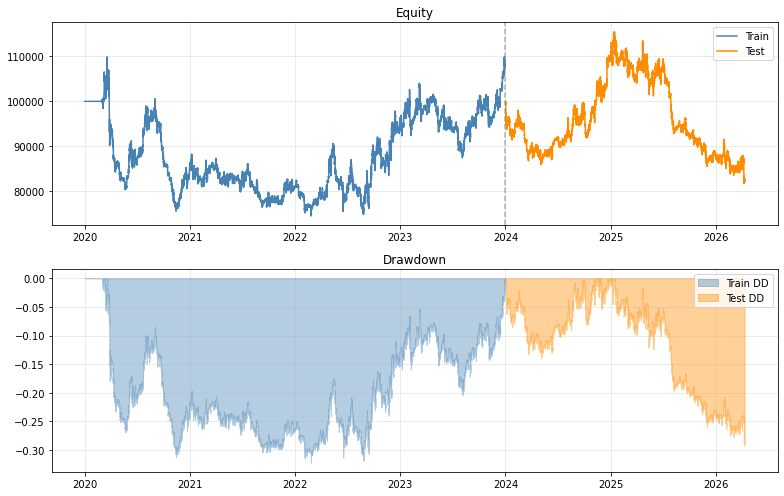

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

axes[0].plot(eq_train.index, eq_train['equity'], label='Train', color='steelblue')
axes[0].plot(eq_test.index, eq_test['equity'], label='Test', color='darkorange')
axes[0].axvline(pd.to_datetime(SPLIT_DATE), color='grey', linestyle='--', alpha=0.6)
axes[0].set_title('Equity')
axes[0].legend()
axes[0].grid(alpha=0.3)

dd_train = eq_train['equity'] / eq_train['equity'].cummax() - 1
dd_test = eq_test['equity'] / eq_test['equity'].cummax() - 1
axes[1].fill_between(dd_train.index, dd_train, 0, color='steelblue', alpha=0.4, label='Train DD')
axes[1].fill_between(dd_test.index, dd_test, 0, color='darkorange', alpha=0.4, label='Test DD')
axes[1].set_title('Drawdown')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
print(f'Test trades: {len(trades_test)}')
trades_test.head(10)

Test trades: 11272


,timestamp,symbol,trade_units,fill_price,commission,position_after
0,2024-01-01 18:00:00,NZDUSD,"90,000.0000",0.6324,2.8455,"90,000.0000"
1,2024-01-01 22:00:00,EURUSD,"52,000.0000",1.1045,2.8716,"52,000.0000"
2,2024-01-01 22:00:00,GBPUSD,"45,000.0000",1.2732,2.8645,"45,000.0000"
3,2024-01-01 22:00:00,USDJPY,"-57,000.0000",140.8950,2.8500,"-57,000.0000"
4,2024-01-01 22:00:00,USDCHF,"-55,000.0000",0.8403,2.7504,"-55,000.0000"
5,2024-01-01 22:00:00,AUDUSD,"84,000.0000",0.6808,2.8591,"84,000.0000"
6,2024-01-01 22:00:00,USDCAD,"-57,000.0000",1.3245,2.8502,"-57,000.0000"
7,2024-01-05 15:00:00,GBPUSD,"-14,000.0000",1.2751,0.8926,"31,000.0000"
8,2024-01-05 16:00:00,GBPUSD,"-9,000.0000",1.2738,0.5732,"22,000.0000"
9,2024-01-05 17:00:00,GBPUSD,"-6,000.0000",1.2723,0.3817,"16,000.0000"


## 9. Simple benchmark check

Here I just compare against holding EUR/USD over the test period.


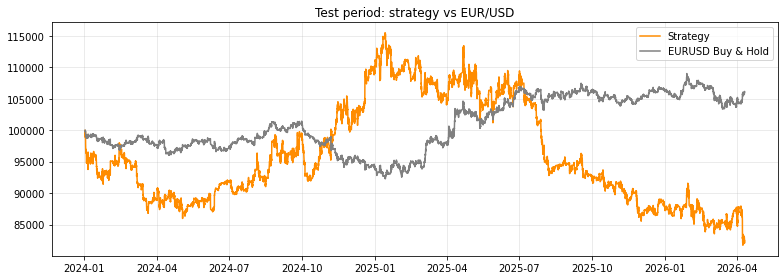

In [20]:
bench_close = data['EURUSD'].loc[SPLIT_DATE:]['close']
bench_eq = 100_000 * (bench_close / bench_close.iloc[0])

strat_eq = eq_test['equity'] / eq_test['equity'].iloc[0] * 100_000

plt.figure(figsize=(11, 4))
plt.plot(strat_eq.index, strat_eq, label='Strategy', color='darkorange')
plt.plot(bench_eq.index, bench_eq, label='EURUSD Buy & Hold', color='grey')
plt.title('Test period: strategy vs EUR/USD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 3-hour live-style check

Since the project needs a short live trading window, I also sample 3-hour windows from the test period and look at trade frequency.


In [21]:
import random

def simulate_live_window(seed=None, n_hours=3, n_runs=1, verbose=True):
    rng = random.Random(seed)
    # test-period timestamps
    timeline = sorted(set().union(*[df.loc[SPLIT_DATE:].index for df in data.values()]))
    valid_starts = timeline[:max(1, len(timeline) - n_hours - 1)]

    rows = []
    for i in range(n_runs):
        start_ts = rng.choice(valid_starts)
        end_idx = timeline.index(start_ts) + n_hours
        end_ts = timeline[min(end_idx, len(timeline) - 1)]

        eq, trades = run_backtest(data, fitted_params, start=start_ts, end=end_ts)
        n_trades = len(trades)
        pnl = eq['equity'].iloc[-1] - CAPITAL

        rows.append({
            'window_start': start_ts,
            'window_end': end_ts,
            'bars': len(eq),
            'n_trades': n_trades,
            'pnl': pnl
        })
        if verbose:
            per_pair = trades.groupby('symbol').size().to_dict() if n_trades else {}
            print(f'[{i+1:02d}] {start_ts} -> {end_ts}  bars={len(eq)}  trades={n_trades}  pnl={pnl:+,.2f}')
            if per_pair:
                print(f'     per_pair: {per_pair}')
    return pd.DataFrame(rows)


print('=' * 60)
print('Single random 3-hour window:')
print('=' * 60)
simulate_live_window(seed=42, n_hours=3, n_runs=1)

Single random 3-hour window:
[01] 2025-09-05 09:00:00 -> 2025-09-05 12:00:00  bars=4  trades=19  pnl=-485.41
     per_pair: {'AUDUSD': 3, 'EURUSD': 4, 'GBPUSD': 3, 'NZDUSD': 1, 'USDCAD': 4, 'USDCHF': 3, 'USDJPY': 1}


,window_start,window_end,bars,n_trades,pnl
0,2025-09-05 09:00:00,2025-09-05 12:00:00,4,19,-485.4076


In [22]:
print('30 random 3-hour windows:')
print('=' * 60)
dist = simulate_live_window(seed=123, n_hours=3, n_runs=30, verbose=False)
print(f"Trades per window: mean={dist['n_trades'].mean():.2f}  median={dist['n_trades'].median():.0f}  min={dist['n_trades'].min()}  max={dist['n_trades'].max()}")
print(f"Windows with >=1 trade : {(dist['n_trades'] >= 1).sum()} / {len(dist)}")
print(f"Windows with  0 trades : {(dist['n_trades'] == 0).sum()} / {len(dist)}")
print(f"Avg PnL per 3h window  : {dist['pnl'].mean():+,.2f} USD")

30 random 3-hour windows:
Trades per window: mean=8.63  median=7  min=7  max=14
Windows with >=1 trade : 30 / 30
Windows with  0 trades : 0 / 30
Avg PnL per 3h window  : +33.97 USD


## 11. Parameter check

This is not a full optimization step. It is only a quick check to see whether the result completely depends on one specific EWMAC speed choice.


In [23]:
PARAM_GRID = [
    ('fast',    ((32, 128),  (64, 256),   (128, 512))),
    ('current', ((64, 256),  (128, 512),  (256, 1024))),
    ('slow',    ((128, 512), (256, 1024), (512, 2048))),
]

grid_rows = []
for name, spans in PARAM_GRID:
    try:
        # refit with another speed set
        orig_pairs = FAST_SLOW_PAIRS

        local_params = {}
        for sym, df in data.items():
            train_df = df.loc[:SPLIT_DATE]
            close = train_df['close'].astype(float)
            price_vol = calc_price_vol(close)
            
            raw_signals = {}
            for fast, slow in spans:
                raw_signals[f'ewmac_{fast}_{slow}'] = calc_ewmac(close, fast, slow, price_vol)
            # keep this comparison simple
            
            scalars = {f'ewmac_{f}_{s}': calc_scalar(raw_signals[f'ewmac_{f}_{s}']) for f, s in spans}
            
            forecast_df = pd.DataFrame(index=train_df.index)
            for fast, slow in spans:
                key = f'ewmac_{fast}_{slow}'
                forecast_df[f'forecast_{key}'] = (raw_signals[key] * scalars[key]).clip(-CAP_FORECAST, CAP_FORECAST)
            
            # equal weights
            n = len(spans)
            rule_weights = {f'forecast_ewmac_{f}_{s}': 1.0/n for f, s in spans}
            
            combined = sum(forecast_df[c] * w for c, w in rule_weights.items())
            x = combined.replace([np.inf, -np.inf], np.nan).dropna()
            mac = x.abs().mean()
            fdm = TARGET_FORECAST / mac if mac > 0 else 1.0
            
            local_params[sym] = {'scalars': scalars, 'rule_weights': rule_weights, 'fdm': fdm, '_spans': spans}
        
        # custom transform for this small check
        def transform_custom(df, params):
            spans_local = params['_spans']
            close = df['close'].astype(float)
            price_vol = calc_price_vol(close)
            out = pd.DataFrame(index=df.index)
            out['close'] = close
            out['price_vol_points'] = price_vol
            for fast, slow in spans_local:
                key = f'ewmac_{fast}_{slow}'
                raw = calc_ewmac(close, fast, slow, price_vol)
                out[f'forecast_{key}'] = (raw * params['scalars'][key]).clip(-CAP_FORECAST, CAP_FORECAST)
            combined_raw = sum(out[c] * w for c, w in params['rule_weights'].items())
            combined = (combined_raw * params['fdm']).clip(-CAP_FORECAST, CAP_FORECAST)
            out['combined_forecast'] = combined
            return out
        
        # lightweight wrapper for this section
        class StrategyWrapperCustom:
            def __init__(self, fitted_params, full_data):
                self.signals = {}
                for sym, params in fitted_params.items():
                    self.signals[sym] = transform_custom(full_data[sym], params)
            def on_market(self, ev):
                out = []
                for sym, row in ev.bars.items():
                    sig_df = self.signals.get(sym)
                    if sig_df is None or ev.timestamp not in sig_df.index:
                        continue
                    sr = sig_df.loc[ev.timestamp]
                    f = sr.get('combined_forecast', np.nan)
                    pv = sr.get('price_vol_points', np.nan)
                    if not np.isfinite(f) or not np.isfinite(pv) or pv <= 0:
                        continue
                    out.append(SignalEvent(
                        timestamp=ev.timestamp, symbol=sym, forecast=float(f),
                        price_vol_points=float(pv), close=float(row['close']),
                        quote_to_account=float(row.get('quote_to_account', 1.0))))
                return out
        
        dh = DataHandler(data, start=SPLIT_DATE)
        strat = StrategyWrapperCustom(local_params, data)
        port = Portfolio(dh.symbols, capital=CAPITAL)
        exe = ExecutionHandler(dh)
        events = queue.Queue()
        for mkt in dh:
            events.put(mkt)
            while not events.empty():
                ev = events.get()
                if isinstance(ev, MarketEvent):
                    port.on_market(ev)
                    for sig in strat.on_market(ev):
                        events.put(sig)
                elif isinstance(ev, SignalEvent):
                    o = port.on_signal(ev)
                    if o: events.put(o)
                elif isinstance(ev, OrderEvent):
                    f = exe.execute(ev, port)
                    if f: events.put(f)
                elif isinstance(ev, FillEvent):
                    port.on_fill(ev)
        
        eq = pd.DataFrame(port.equity_curve).set_index('timestamp')
        eq['returns'] = eq['equity'].pct_change().fillna(0.0)
        mt = calc_metrics(eq, trades=pd.DataFrame(port.trades), capital0=CAPITAL)
        
        grid_rows.append({
            'config': name, 'spans': str(spans),
            'Sharpe': mt['Sharpe'], 'CAGR': mt['CAGR'],
            'MaxDD': mt['MaxDrawdown'], 'NumTrades': mt.get('NumTrades', 0)
        })
        print(f'{name:>8}  Sharpe={mt["Sharpe"]:+.3f}  CAGR={mt["CAGR"]:+.3f}  MaxDD={mt["MaxDrawdown"]:+.3f}')
    except Exception as e:
        print(f'{name}: failed -> {e}')

pd.DataFrame(grid_rows)

    fast  Sharpe=-0.714  CAGR=-0.134  MaxDD=-0.339
 current  Sharpe=-0.343  CAGR=-0.076  MaxDD=-0.267
    slow  Sharpe=-0.345  CAGR=-0.078  MaxDD=-0.218


,config,spans,Sharpe,CAGR,MaxDD,NumTrades
0,fast,"((32, 128), (64, 256), (128, 512))",-0.7139,-0.1345,-0.3389,10096
1,current,"((64, 256), (128, 512), (256, 1024))",-0.3434,-0.0761,-0.2672,6457
2,slow,"((128, 512), (256, 1024), (512, 2048))",-0.3446,-0.0783,-0.2180,4134
